# 112_shap.ipynb
Use the SHAP library to try and do another explanation of the features.

In [30]:
# Before using SHAP, it always must be initialized.

import shap

shap.initjs()

## Import the data

In [31]:
from pathlib import Path

# Select which model to run
path = Path.cwd().parent.parent
SETUP = {'PC1': {'X': path / "data" / "interim" / "pc_by_feature_group_for_patients.csv",
                 'hyperparameters_file' : path / "notebooks" / "modeling" / "optimal_params_pc1.json"},
        'PC1_3' : {'X' : path / "data" / "interim" / "pc1_to_3_by_feature_group_for_patients.csv",
                   'hyperparameters_file' : path / "notebooks" / "modeling" / "optimal_params_pc1_to_3.json"},
        'ALL_IMG' : {'X' : path / "data" / "raw" / "imagingFeatures.csv",
                     'hyperparameters_file' : path / "notebooks" / "modeling" / "optimal_params_all_image_features.json"}}
MODEL = 'ALL_IMG'
TARGET = 'Mol Subtype'

# Set up test and training data
import pandas as pd
from sklearn.preprocessing import LabelEncoder
trainPatientID = (pd.read_csv(path / "data" / "processed" / "trainDataPatientID.csv")
                  .drop(['Unnamed: 0'], axis=1)
                  .rename(columns={'Patient.ID' : 'Patient ID'}, errors='ignore'))
testPatientID = (pd.read_csv(path / "data" / "processed" / "testDataPatientID.csv")
                  .drop(['Unnamed: 0'], axis=1)
                  .rename(columns={'Patient.ID' : 'Patient ID'}, errors='ignore'))
features = pd.read_csv(SETUP[MODEL]['X'])
features.rename(columns={'Patient.ID': 'Patient ID'}, inplace=True, errors='ignore')

clin = pd.read_csv(path / "data" / "raw" / "clinicalData_clean.csv")

data = features.merge(clin[['Patient ID', TARGET]], on='Patient ID', how='inner')
data = data.drop('Unnamed: 0', axis=1, errors='ignore')

y = data[[TARGET, 'Patient ID']]
if y[TARGET].dtype == 'object' or y[TARGET].dtype.name == 'category':
    le = LabelEncoder()
    y[TARGET] = le.fit_transform(y[TARGET])

yTrain = y[y['Patient ID'].isin(trainPatientID['Patient ID'])][TARGET]
yTest = y[y['Patient ID'].isin(testPatientID['Patient ID'])][TARGET]

XTrain = (data[data['Patient ID'].isin(trainPatientID['Patient ID'])]
          .drop(['Patient ID', TARGET], axis=1))
XTest = (data[data['Patient ID'].isin(testPatientID['Patient ID'])]
         .drop(['Patient ID', TARGET], axis=1))

In [32]:
# Fetch the optimal hyperparameters for this model
import json
with open(SETUP[MODEL]['hyperparameters_file'], 'r') as file:
    model_info = json.load(file)
for model in model_info:
    if model['model'] == 'RandomForest':
        best_rf_params = model['best_params']


## Train the model
Using the previously discovered optimal hyperparameters

In [39]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(**best_rf_params, class_weight='balanced')
clf.fit(XTrain, yTrain)

explainer = shap.TreeExplainer(clf)
shap_values = explainer(XTest)

In [40]:
# See accuracy on the test data
clf.score(XTest, yTest)

0.6395348837209303

In [41]:
# Debugging
# Get predicted class indices for each test sample
pred_class_indices = clf.predict(XTest)

# If you want the class labels (not just indices), use:
class_labels = clf.classes_
pred_class_labels = class_labels[pred_class_indices]

# Print sanity-checks
print("Training label distribution:")
print(yTrain.value_counts())
print("Test label distribution:")
print(yTest.value_counts())
print("Any NaNs in XTrain?", XTrain.isnull().any().any())
print("Any NaNs in XTest?", XTest.isnull().any().any())
print("Any constant columns?", (XTrain.nunique() <= 1).sum())
print("Train accuracy:", clf.score(XTrain, yTrain))
print("Test accuracy:", clf.score(XTest, yTest))
print("Unique labels in yTrain:", yTrain.unique())
print("Unique labels in yTest:", yTest.unique())

Training label distribution:
Mol Subtype
0    438
3    128
1     78
2     44
Name: count, dtype: int64
Test label distribution:
Mol Subtype
0    107
3     30
1     22
2     13
Name: count, dtype: int64
Any NaNs in XTrain? False
Any NaNs in XTest? False
Any constant columns? 0
Train accuracy: 1.0
Test accuracy: 0.6395348837209303
Unique labels in yTrain: [3 0 1 2]
Unique labels in yTest: [0 3 1 2]


## Waterfall plot
* Displays an explanation for one particular prediction
* Consume a single row of an Explanation object as input `shap_values[0, :, pred_class[0]`]
* The bottom displays the expected value of the output
* Each row shows the positive or negative contribution of that feature on how it moved the value to the prediction
[documentation](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html)

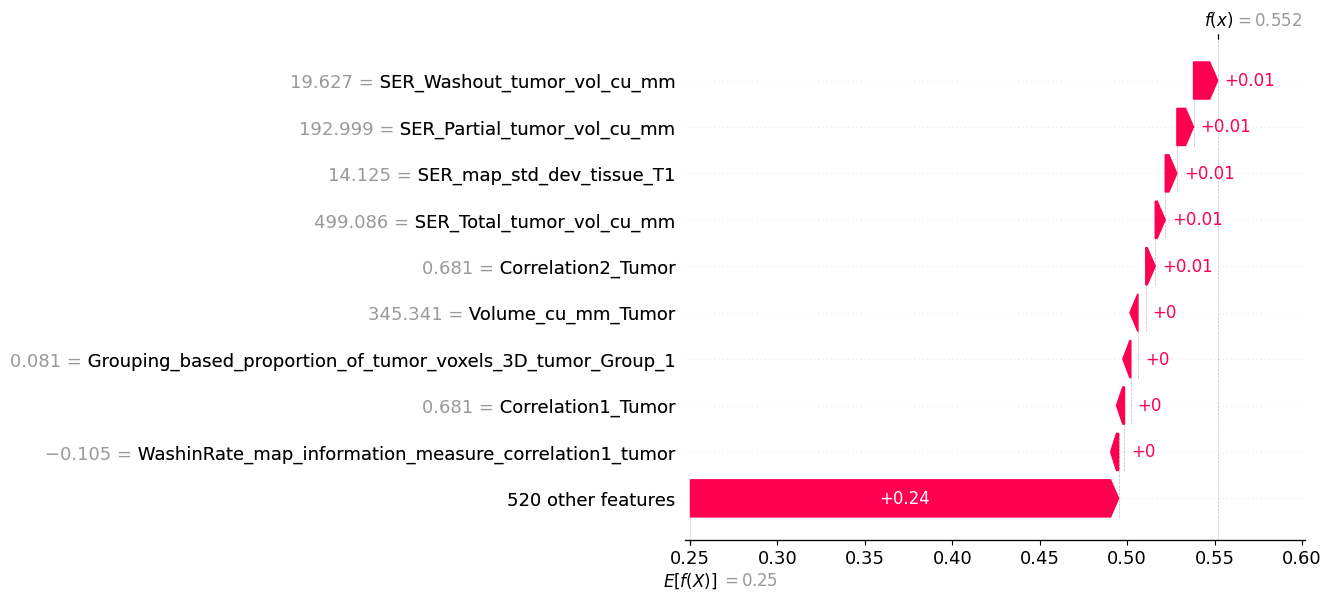

In [42]:
pred_class = clf.predict(XTest)
shap.plots.waterfall(shap_values[0, :, pred_class[0]],
                     max_display=10)

## Summary plot

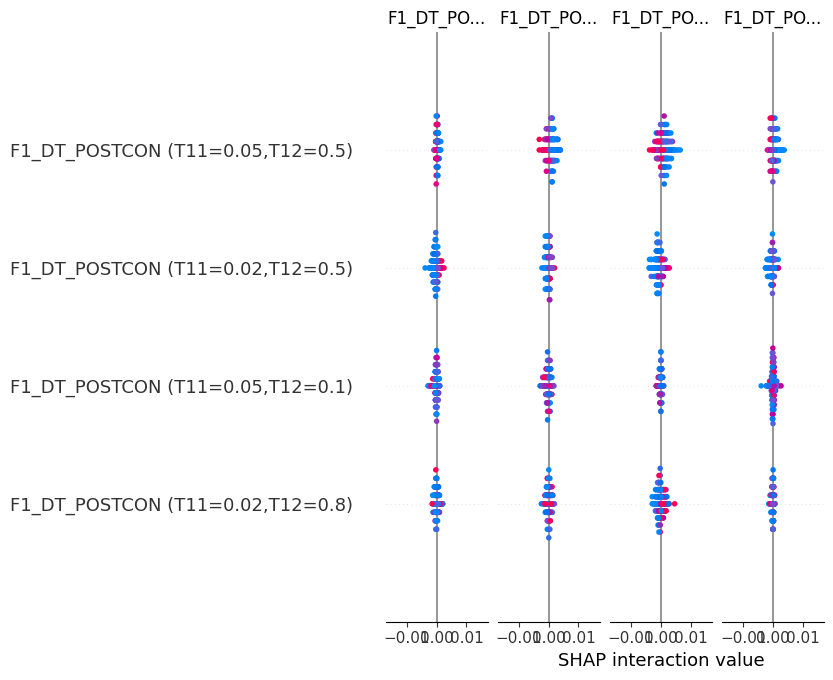

In [43]:
# Create a SHAP summary plot for all features across all test samples
shap.summary_plot(shap_values.values, XTest, feature_names=XTest.columns)

AttributeError: 'numpy.ndarray' object has no attribute 'figure'

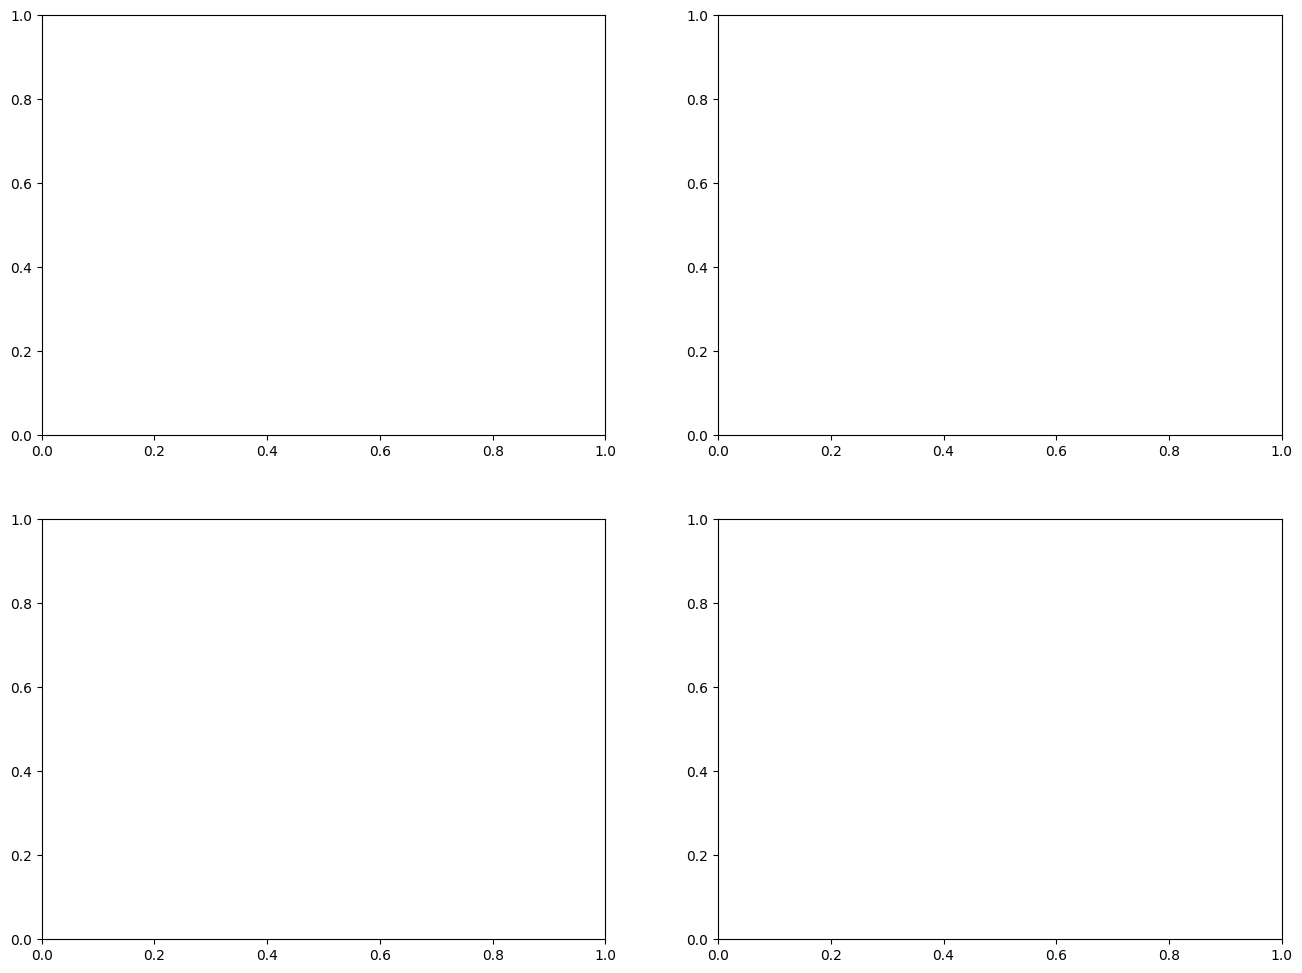

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, class_name in enumerate(class_labels):
    plt.sca(axes[i])
    shap.summary_plot(
        shap_values.values[:, :, i],
        XTest,
        feature_names=XTest.columns,
        show=False
    )
    axes[i].set_title(f"SHAP summary for class: {class_name}")

plt.show()